# 04 — Analyse results

Loads the CSVs written by notebook 03 and renders the cross-scenario tables and plots used in Chapters 5 and 6 of the thesis.

Headline metrics now include:
- started vs. completed charging events,
- % of agents who charged at least once,
- % of agents who waited at least once,
- median / 95th-percentile waiting time,
- mean waiting time *among waiters only*,
- total queue-minutes and max queue length.

In [1]:
import sys
from pathlib import Path
PROJECT = Path.cwd().resolve().parent
if str(PROJECT) not in sys.path: sys.path.insert(0, str(PROJECT))

import pandas as pd
import matplotlib.pyplot as plt
from src import config

In [2]:
summary = pd.read_csv(config.TABLES_DIR / 'scenario_summary.csv')
agents = pd.read_csv(config.TABLES_DIR / 'agent_results.csv')
stations = pd.read_csv(config.TABLES_DIR / 'station_results.csv')
summary.T  # transpose so all metrics fit vertically

,0,1,2
scenario,S1_real,S2_clustered,S3_distributed
n_agents,500,500,500
n_stations,16,16,16
total_ports,27,27,27
completed_trips,1362,1216,1396
failed_trips,0,0,0
stranded_agents,21,19,20
started_charging_events,204,149,212
completed_charging_events,201,146,210
total_queued_agents,139,100,126


### Per-scenario aggregates (agent-level)

In [3]:
agents.groupby('scenario').agg(
    completed_trips=('completed_trips', 'sum'),
    started_charging=('started_charging_events', 'sum'),
    completed_charging=('completed_charging_events', 'sum'),
    times_queued=('times_queued', 'sum'),
    mean_wait=('waiting_time_min', 'mean'),
    median_wait=('waiting_time_min', 'median'),
    p95_wait=('waiting_time_min', lambda s: s.quantile(0.95)),
    max_wait=('waiting_time_min', 'max'),
    mean_detour_m=('detour_distance_m', 'mean'),
    median_detour_m=('detour_distance_m', 'median'),
    stranded=('stranded', 'sum'),
)

,completed_trips,started_charging,completed_charging,times_queued,mean_wait,median_wait,p95_wait,max_wait,mean_detour_m,median_detour_m,stranded
scenario,,,,,,,,,,,
S1_real,1362,204,201,171,38.932,0.0,277.30,545.0,538.305533,0.0,21
S2_clustered,1216,149,146,185,35.384,0.0,293.00,610.0,911.956263,0.0,19
S3_distributed,1396,212,210,152,24.996,0.0,171.55,425.0,431.806495,0.0,20


### Waiters only — the meaningful waiting-time view

In [6]:
waiters = agents[agents['waiting_time_min'] > 0]
waiters = agents[agents["waiting_time_min"] > 0]

waiters_summary = waiters.groupby("scenario")["waiting_time_min"].agg(
    count="count",
    mean="mean",
    median="median",
    p95=lambda s: s.quantile(0.95),
    max="max"
)

waiters_summary

,count,mean,median,p95,max
scenario,,,,,
S1_real,139,140.043165,93.0,413.10,545.0
S2_clustered,100,176.920000,89.0,538.15,610.0
S3_distributed,126,99.190476,60.5,318.00,425.0


### Per-scenario aggregates (station-level)

In [7]:
stations.groupby('scenario').agg(
    n_stations=('station_id', 'count'),
    total_ports=('n_ports', 'sum'),
    mean_util=('utilisation', 'mean'),
    max_util=('utilisation', 'max'),
    total_queue_min=('total_queue_minutes', 'sum'),
    max_queue=('max_queue', 'max'),
    total_started=('total_started', 'sum'),
    total_completed=('total_completed', 'sum'),
)

,n_stations,total_ports,mean_util,max_util,total_queue_min,max_queue,total_started,total_completed
scenario,,,,,,,,
S1_real,16,27,0.367101,0.998611,25537,22,204,201
S2_clustered,16,27,0.233073,0.997222,51394,47,149,146
S3_distributed,16,27,0.317187,0.983333,15480,20,212,210


### Pre-rendered figures (from notebook 03)

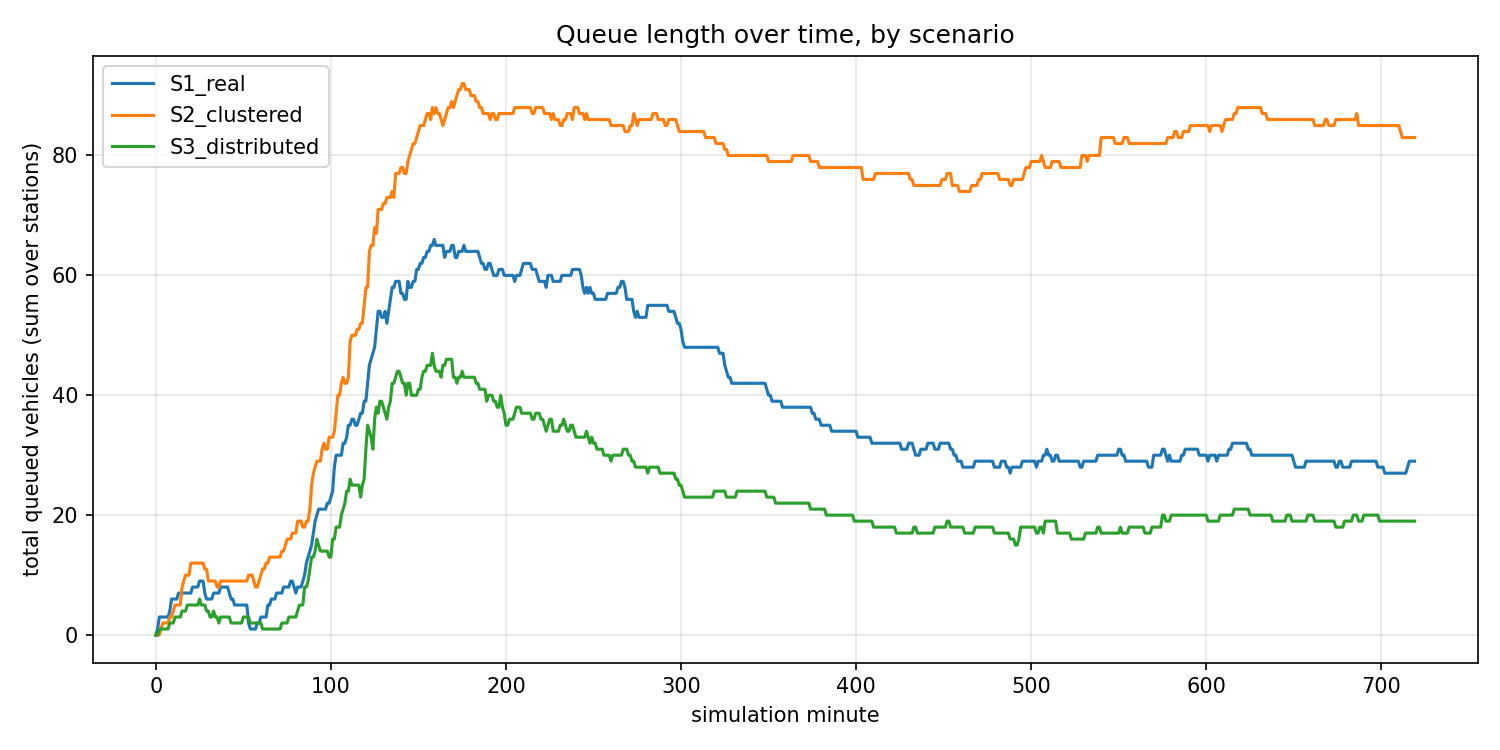

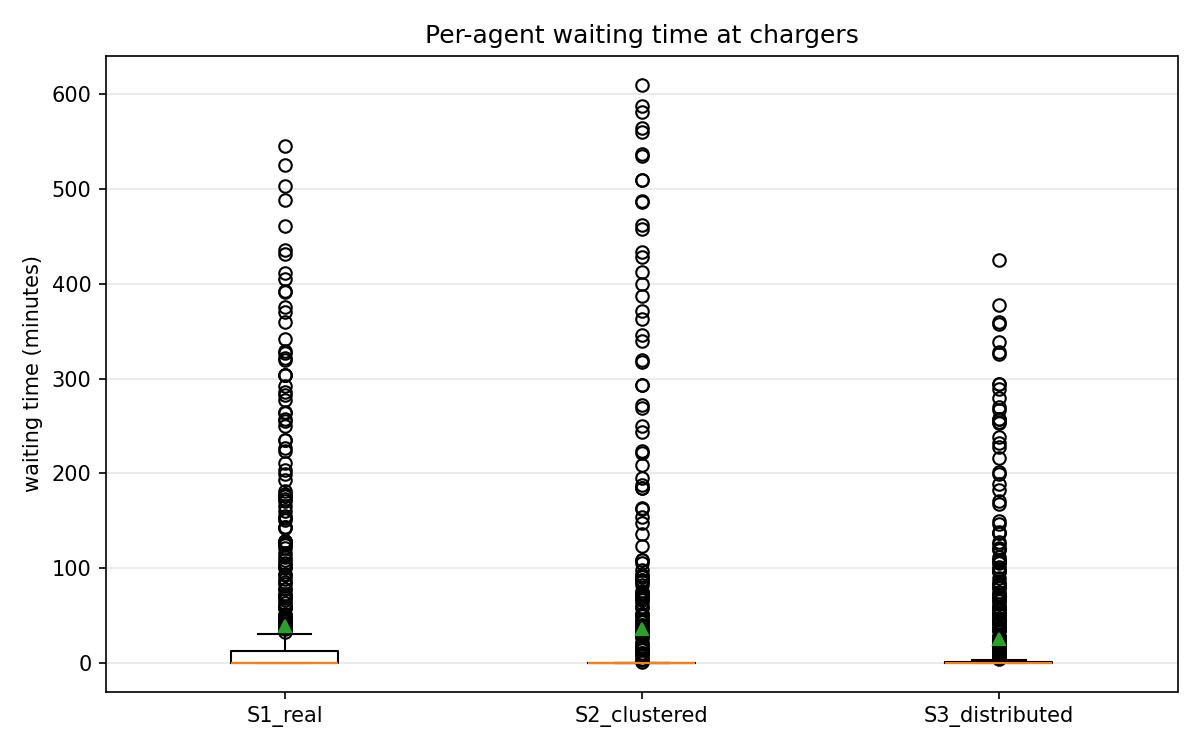

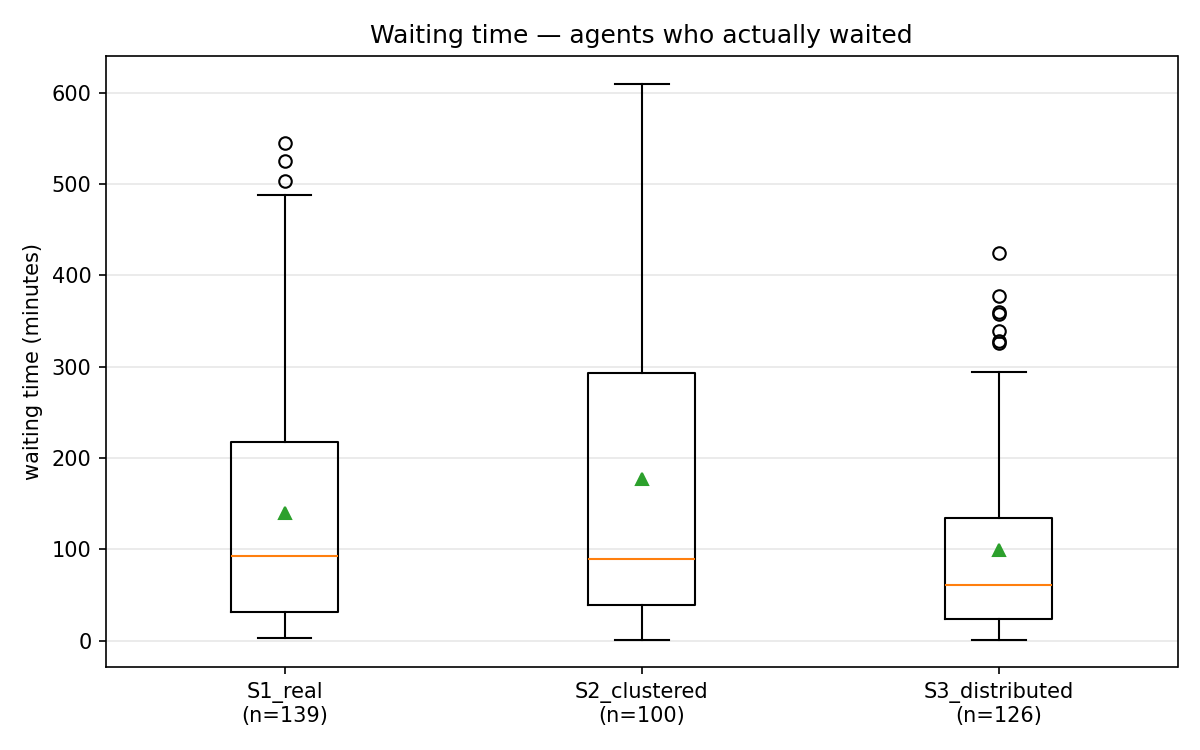

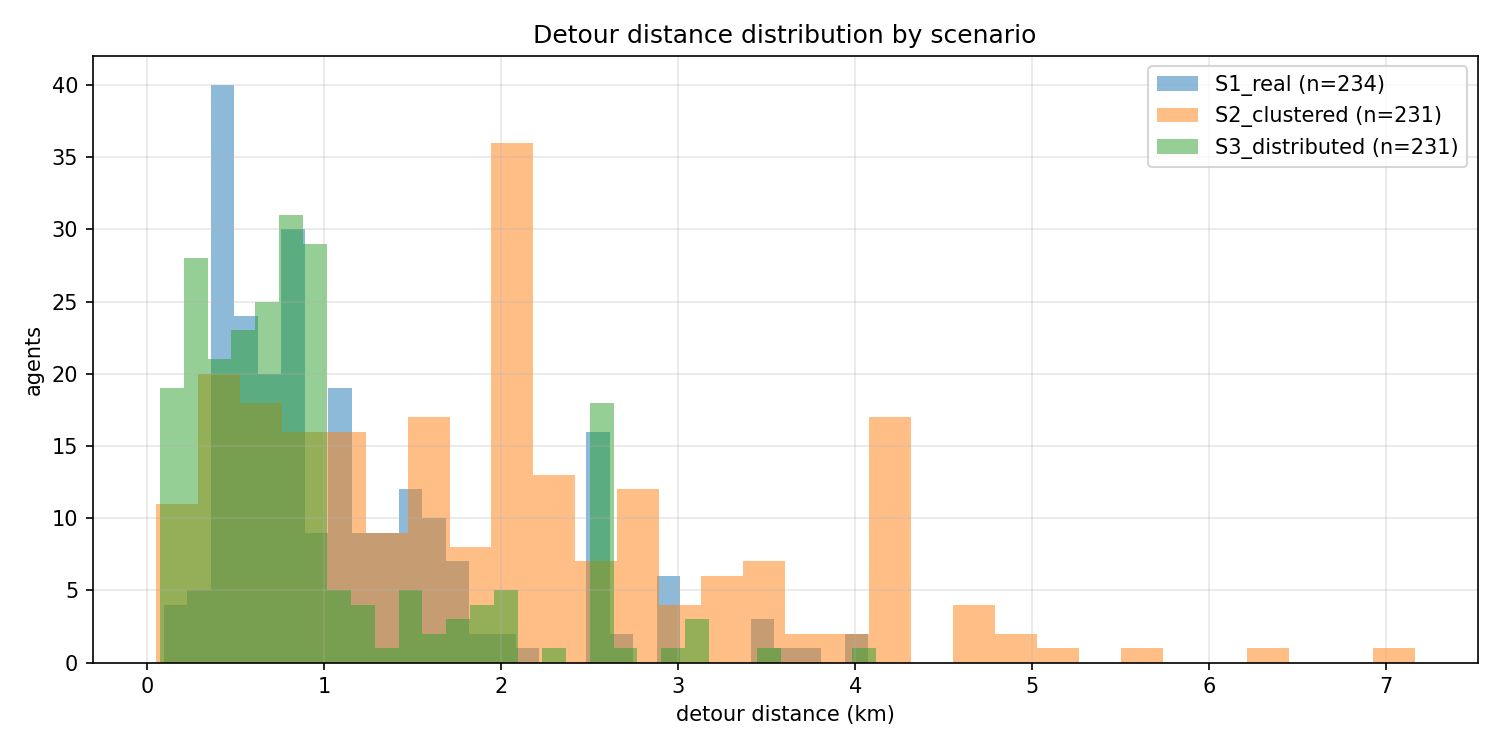

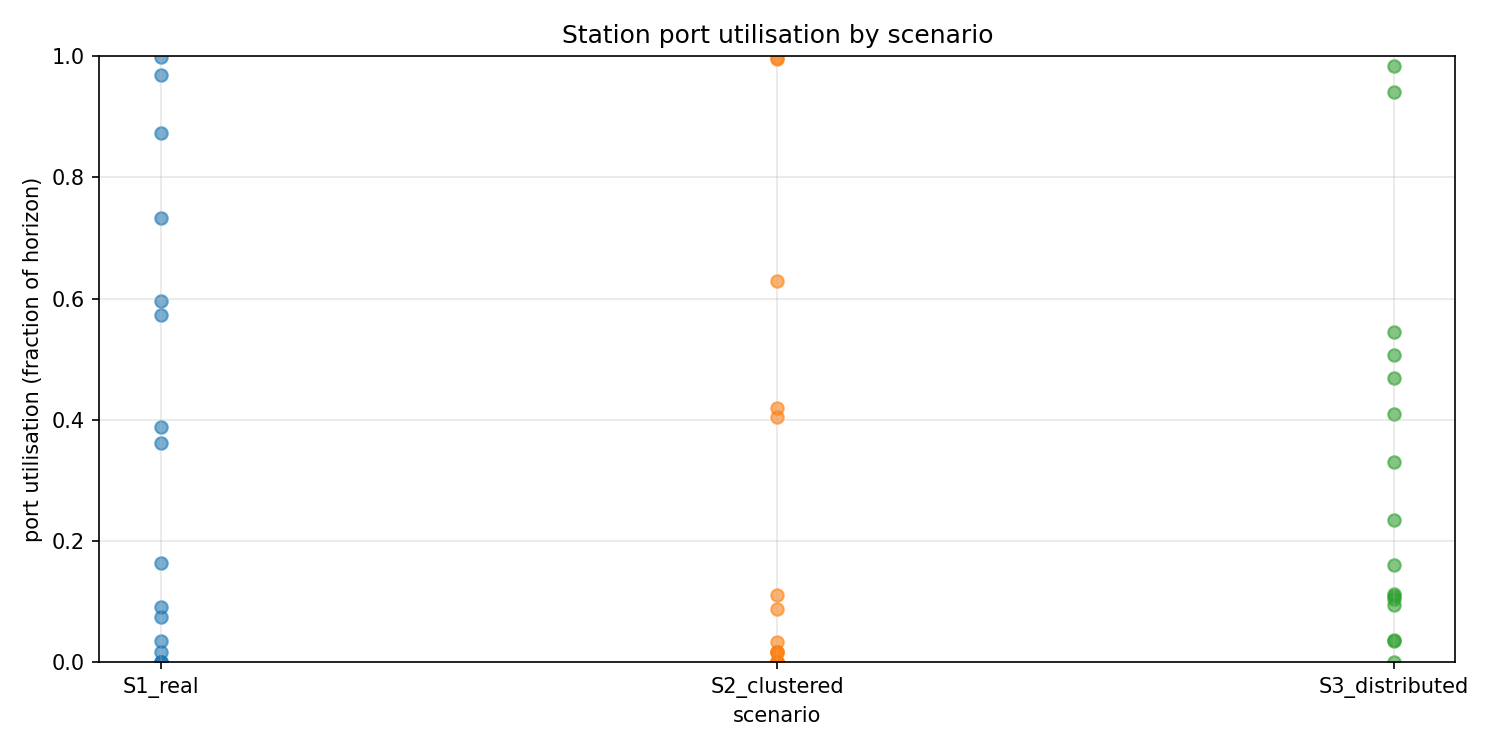

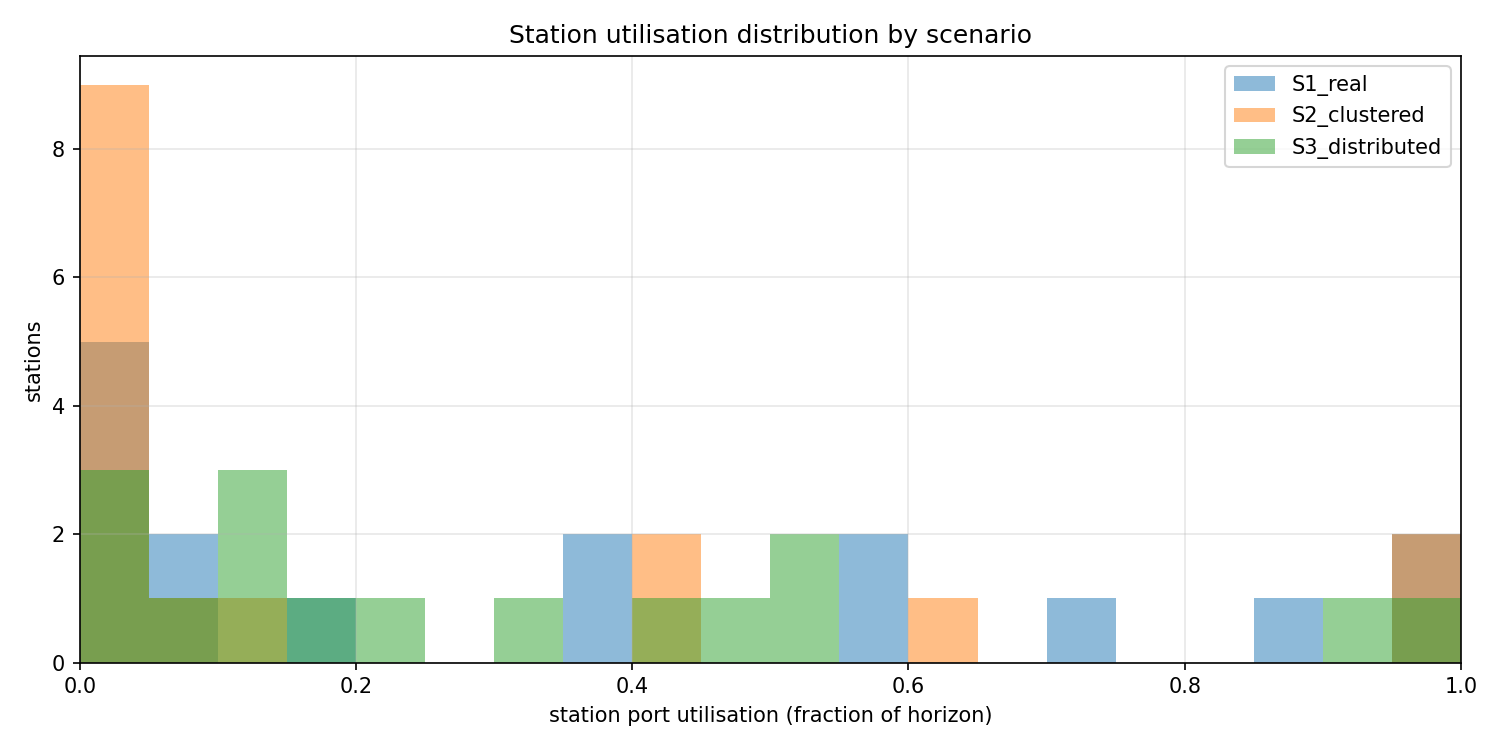

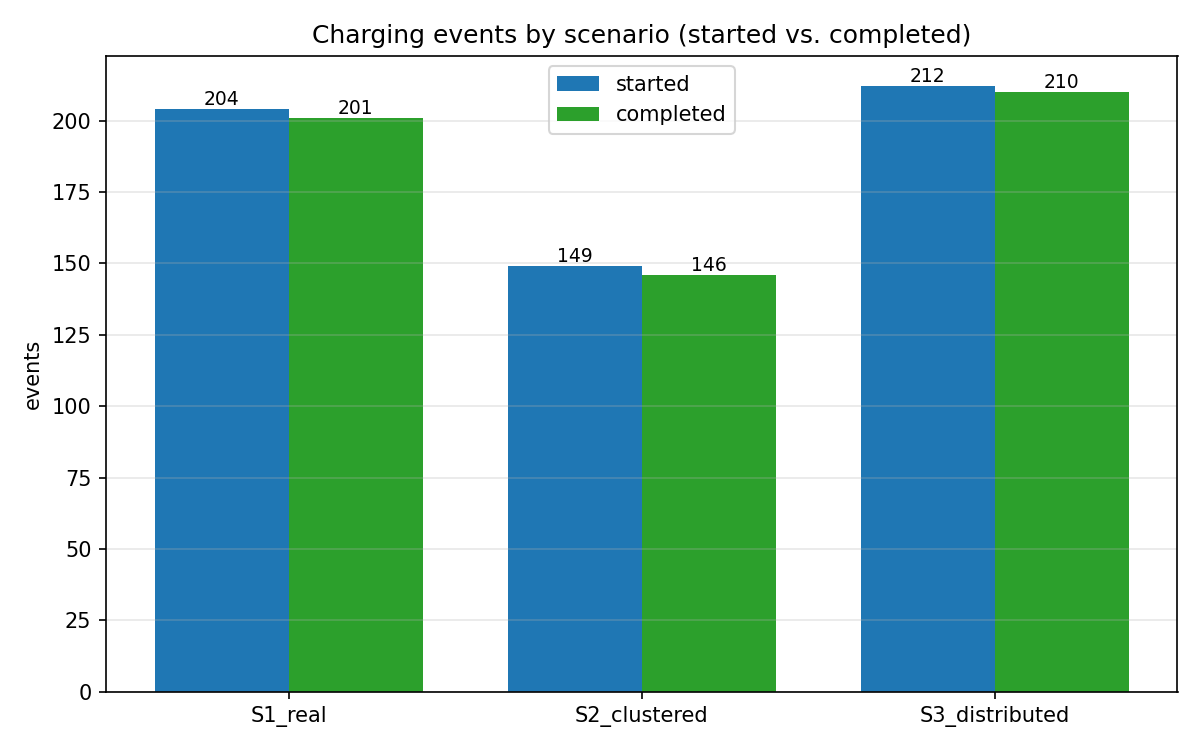

In [8]:
from IPython.display import Image, display
for name in [
    'queue_over_time.png',
    'scenario_comparison_waiting_time.png',
    'waiting_time_waiters_only.png',
    'detour_distribution.png',
    'station_utilisation.png',
    'utilisation_histogram.png',
    'charging_events_by_scenario.png',
]:
    p = config.FIGURES_DIR / name
    if p.exists():
        display(Image(filename=str(p)))
    else:
        print(f'missing: {p}')